# Smart Waste Sorting Classification

Prepared by: Iffraah Rehman(W216165700)

Computer Vision Artificial Intelligence (ITAI-1378)

Date: 08 May, 2026

## Project Goal
Waste sorting is often done manually, which can be slow and inaccurate. Many recyclable items are thrown into regular trash because people may not know the correct category.

This notebook builds a **computer vision waste classification system** using **MobileNetV2 transfer learning**.

## Workflow
**Image of Waste → AI Model → Waste Category → Display Result**

## Stakeholders
- Recycling centers  
- Waste management companies  
- Environmental organizations  
- Cities and municipalities  

## Why This Matters
Incorrect waste sorting increases landfill waste and reduces recycling efficiency. An automated image classification system can help identify waste categories and support better recycling decisions.

## Dataset

Dataset used: **Garbage Classification Dataset** from Kaggle  
Link: https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification

The dataset contains 6 classes:

- cardboard
- glass
- metal
- paper
- plastic
- trash

According to the Kaggle dataset page, the class distribution is approximately:
- cardboard: 393 images
- glass: 491 images
- metal: 400 images
- paper: 584 images
- plastic: 472 images
- trash: 127 images

> Note: The dataset is slightly imbalanced, especially the `trash` class, so data augmentation is useful.

## 1. Install and Import Libraries

Run the installation cell only if the required libraries are not already installed.

In [ ]:
# Optional: install required libraries if needed
# !pip install tensorflow matplotlib numpy pandas scikit-learn seaborn kaggle

In [1]:
import os
import shutil
import random
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

print("✅ Environment setup complete!")
print("🎯 Ready to build Smart Image Sorting Classifier!")

✅ Environment setup complete!
🎯 Ready to build Smart Image Sorting Classifier!


## 2. Set Dataset Path

After downloading/unzipping, the folder should contain image class folders such as:
`cardboard`, `glass`, `metal`, `paper`, `plastic`, and `trash`.

Update the path below if your folder structure is different.

In [3]:
import zipfile

zip_path = "/content/archive.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [4]:
import os

os.listdir("/content/dataset")

['zero-indexed-files.txt',
 'one-indexed-files.txt',
 'one-indexed-files-notrash_val.txt',
 'Garbage classification',
 'one-indexed-files-notrash_train.txt',
 'one-indexed-files-notrash_test.txt',
 'garbage classification']

In [8]:
import os
from pathlib import Path

# Common paths:
# Local/Colab after unzip:
#DATASET_PATH = Path("garbage-classification/Garbage classification/Garbage classification")
DATASET_PATH = Path("/content/dataset/garbage classification/Garbage classification")

# Kaggle notebook example:
# DATASET_PATH = Path("/kaggle/input/garbage-classification/Garbage classification/Garbage classification")

print("Dataset path exists:", DATASET_PATH.exists())
print("Dataset path:", DATASET_PATH)

if DATASET_PATH.exists():
    print("Folders:", sorted([p.name for p in DATASET_PATH.iterdir() if p.is_dir()]))
else:
    print("Please update DATASET_PATH to the folder that contains the class subfolders.")

Dataset path exists: True
Dataset path: /content/dataset/garbage classification/Garbage classification
Folders: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## 4. Explore Dataset

This section counts images in each waste category.

,Class,Image Count
0,cardboard,403
1,glass,501
2,metal,410
3,paper,594
4,plastic,482
5,trash,137


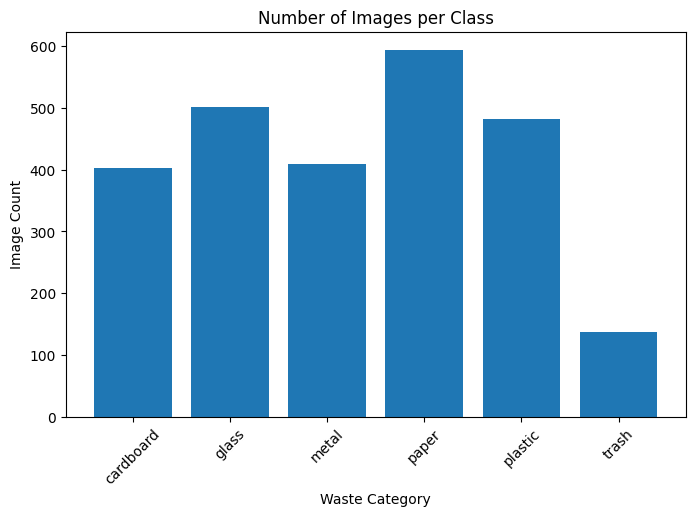

In [9]:
class_counts = {}

if DATASET_PATH.exists():
    for class_folder in sorted(DATASET_PATH.iterdir()):
        if class_folder.is_dir():
            image_files = list(class_folder.glob("*"))
            image_files = [f for f in image_files if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]
            class_counts[class_folder.name] = len(image_files)

    counts_df = pd.DataFrame(list(class_counts.items()), columns=["Class", "Image Count"])
    display(counts_df)

    plt.figure(figsize=(8, 5))
    plt.bar(counts_df["Class"], counts_df["Image Count"])
    plt.title("Number of Images per Class")
    plt.xlabel("Waste Category")
    plt.ylabel("Image Count")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Dataset path not found. Please fix DATASET_PATH first.")

## 5. Display Sample Images

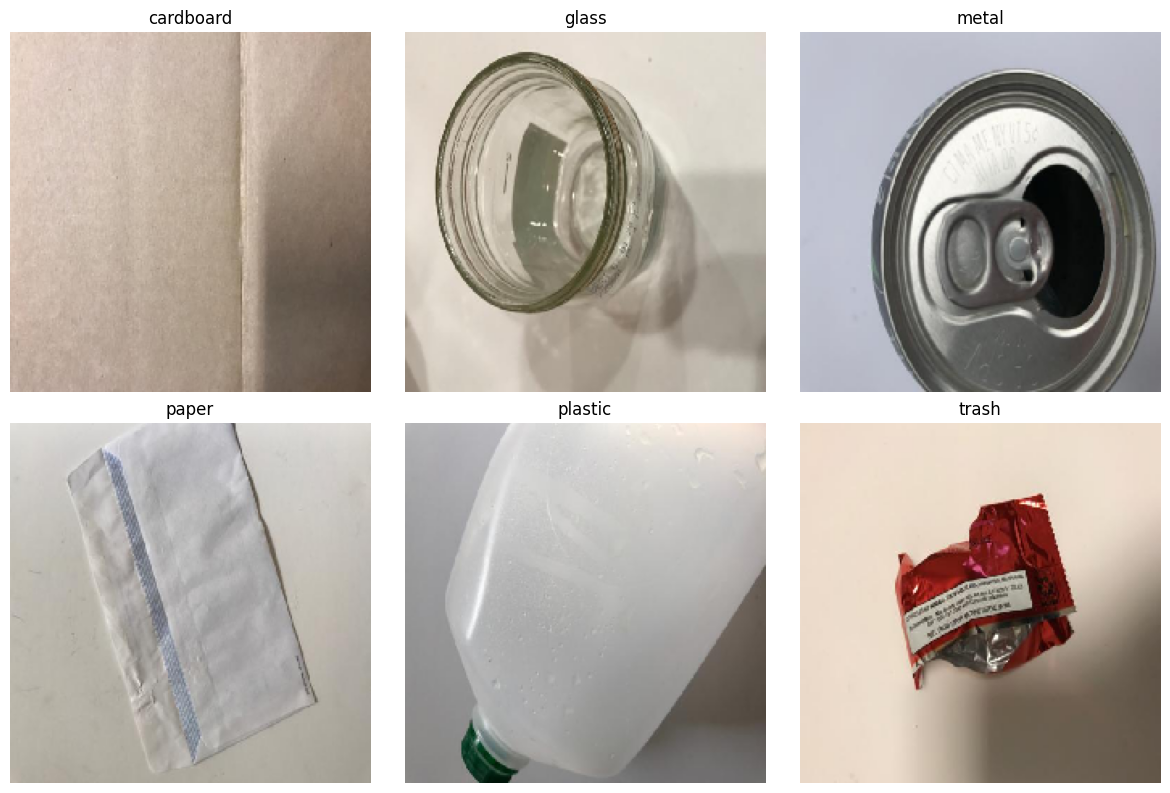

In [10]:
if DATASET_PATH.exists():
    plt.figure(figsize=(12, 8))
    classes = sorted([p.name for p in DATASET_PATH.iterdir() if p.is_dir()])

    image_index = 1
    for class_name in classes:
        class_folder = DATASET_PATH / class_name
        image_files = [f for f in class_folder.glob("*") if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]
        if len(image_files) > 0:
            sample_image = random.choice(image_files)
            img = tf.keras.utils.load_img(sample_image, target_size=(224, 224))

            plt.subplot(2, 3, image_index)
            plt.imshow(img)
            plt.title(class_name)
            plt.axis("off")
            image_index += 1

    plt.tight_layout()
    plt.show()
else:
    print("Dataset path not found.")

## 6. Create Training and Validation Datasets

MobileNetV2 expects images around `224 x 224`.  
We use an 80/20 training-validation split.

In [11]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
Class names: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Number of classes: 6


## 7. Improve Dataset Performance

`cache()` and `prefetch()` help the notebook train faster.

In [12]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## 8. Data Augmentation

Data augmentation helps reduce overfitting by creating slightly modified versions of training images.

In [13]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
], name="data_augmentation")

## 9. Build MobileNetV2 Transfer Learning Model

MobileNetV2 is used as a pretrained feature extractor.  
At first, we freeze the base model and train only the new classification layers.

In [14]:
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 10. Train the Model

In [15]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7
    ),
    ModelCheckpoint(
        "best_waste_mobilenetv2_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 111ms/step - accuracy: 0.2265 - loss: 1.9863 - val_accuracy: 0.3267 - val_loss: 1.6938 - learning_rate: 1.0000e-04
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.3452 - loss: 1.6524 - val_accuracy: 0.4535 - val_loss: 1.4493 - learning_rate: 1.0000e-04
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.4594 - loss: 1.4439 - val_accuracy: 0.5287 - val_loss: 1.2726 - learning_rate: 1.0000e-04
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.5134 - loss: 1.2862 - val_accuracy: 0.5842 - val_loss: 1.1445 - learning_rate: 1.0000e-04
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.5593 - loss: 1.1781 - val_accuracy: 0.6040 - val_loss: 1.0573 - learning_rate: 1.0000e-04
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.6103 - loss: 1.0545 - val_accuracy: 0.6257 - val_loss: 0.9896 - learning_rate: 1.0000e-04
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.603

## 11. Plot Accuracy and Loss

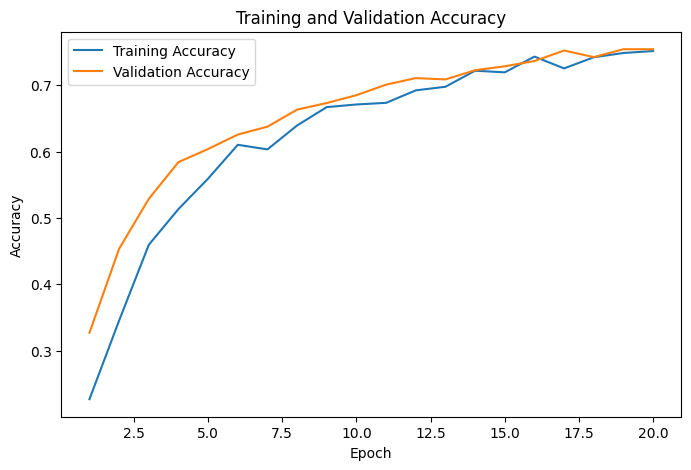

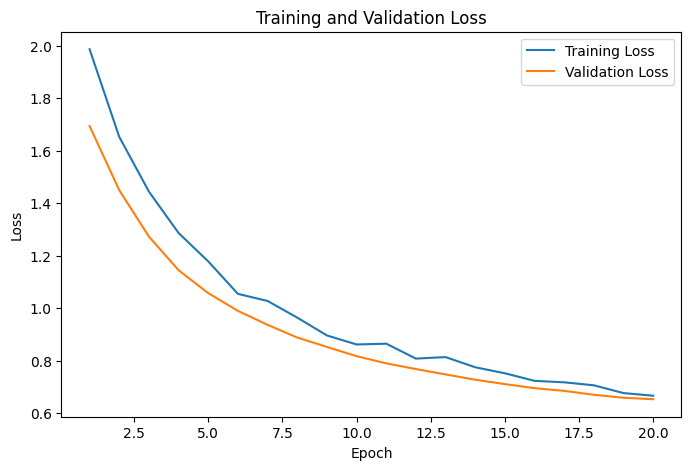

In [16]:
def plot_training_history(history):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, acc, label="Training Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.title("Training and Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_training_history(history)

## 12. Optional Fine-Tuning

After the first training stage, we can unfreeze part of MobileNetV2 and train with a very small learning rate.  
This can improve accuracy, but it may also overfit if the dataset is small.

In [17]:
# Unfreeze the base model for fine-tuning
base_model.trainable = True

# Freeze earlier layers and fine-tune only the later layers
fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

FINE_TUNE_EPOCHS = 10

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 143ms/step - accuracy: 0.6469 - loss: 0.9515 - val_accuracy: 0.7663 - val_loss: 0.6424 - learning_rate: 1.0000e-05
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - accuracy: 0.7141 - loss: 0.7975 - val_accuracy: 0.7743 - val_loss: 0.6255 - learning_rate: 1.0000e-05
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 125ms/step - accuracy: 0.7428 - loss: 0.7230 - val_accuracy: 0.7861 - val_loss: 0.6092 - learning_rate: 1.0000e-05
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - accuracy: 0.7552 - loss: 0.6579 - val_accuracy: 0.8119 - val_loss: 0.5862 - learning_rate: 1.0000e-05
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - accuracy: 0.7770 - loss: 0.6203 - val_accuracy: 0.8178 - val_loss: 0.5742 - learning_rate: 1.0000e-05
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - accuracy: 0.7928 - loss: 0.5752 - val_accuracy: 0.8198 - val_loss: 0.5613 - learning_rate: 1.0000e-05
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 116ms/step - accuracy

## 13. Evaluate the Model

In [18]:
val_loss, val_accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.8416 - loss: 0.5043
Validation Loss: 0.5043
Validation Accuracy: 0.8416


## 14. Classification Report and Confusion Matrix

In [19]:
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

   cardboard       0.87      0.94      0.90        69
       glass       0.88      0.83      0.85       102
       metal       0.74      0.93      0.82        88
       paper       0.94      0.83      0.88       123
     plastic       0.81      0.83      0.82        89
       trash       0.77      0.50      0.61        34

    accuracy                           0.84       505
   macro avg       0.83      0.81      0.81       505
weighted avg       0.85      0.84      0.84       505



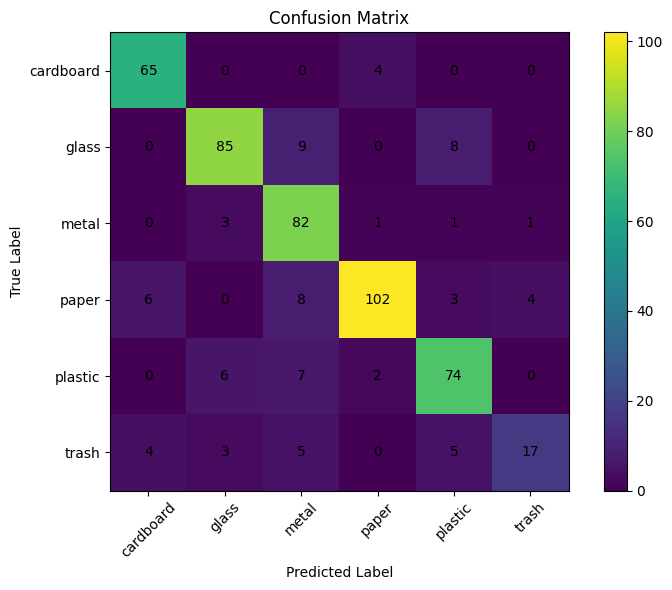

In [20]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(num_classes), class_names, rotation=45)
plt.yticks(range(num_classes), class_names)

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

## 15. Make Prediction on a New Image

Upload or provide the path to any waste image and run the prediction function.

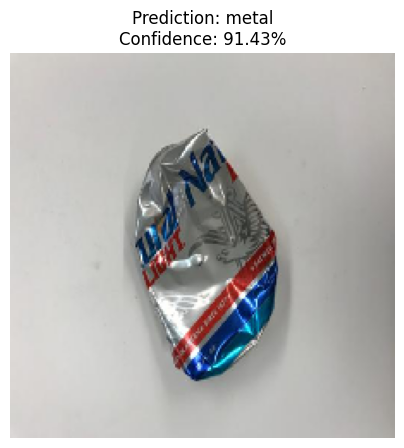

metal 0.914323


In [23]:
def predict_waste_image(image_path, model, class_names):
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array, verbose=0)
    predicted_index = np.argmax(predictions[0])
    confidence = predictions[0][predicted_index]

    predicted_class = class_names[predicted_index]

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2%}")
    plt.show()

    return predicted_class, confidence

# Example:
image_path = "/content/dataset/Garbage classification/Garbage classification/metal/metal102.jpg"
predicted_class, confidence = predict_waste_image(image_path, model, class_names)
print(predicted_class, confidence)

## 16. Display User-Friendly Result

This is the final output format for the waste classification system.

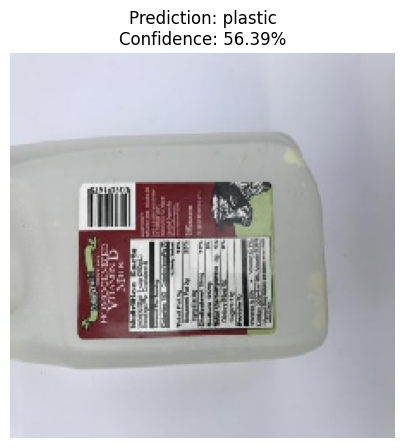

Workflow Result
----------------
Input: Waste Image
AI Model: MobileNetV2 Transfer Learning
Waste Category: plastic
Confidence: 56.39%


In [25]:
def display_waste_result(image_path):
    predicted_class, confidence = predict_waste_image(image_path, model, class_names)

    print("Workflow Result")
    print("----------------")
    print("Input: Waste Image")
    print("AI Model: MobileNetV2 Transfer Learning")
    print(f"Waste Category: {predicted_class}")
    print(f"Confidence: {confidence:.2%}")

# Example:
display_waste_result("/content/dataset/Garbage classification/Garbage classification/plastic/plastic110.jpg")

## 17. Save the Final Model

In [26]:
model.save("final_waste_classifier_mobilenetv2.keras")
print("Model saved as final_waste_classifier_mobilenetv2.keras")

Model saved as final_waste_classifier_mobilenetv2.keras


## 18. Conclusion

In this project, we developed a computer vision system that classifies waste images into categories such as cardboard, glass, metal, paper, plastic, and trash. MobileNetV2 was used because it is lightweight, efficient, and effective for image classification tasks.

The model follows this workflow:

**Image of Waste → MobileNetV2 AI Model → Waste Category → Display Result**

This type of system can help recycling centers, waste management companies, cities, and environmental organizations improve sorting accuracy and reduce landfill waste.

## Future Improvements
- Add more images, especially for the smaller `trash` class
- Use a larger and more balanced dataset
- Test other transfer learning models such as EfficientNetB0 or ResNet50
- Deploy the model as a web app or mobile app
- Add object detection if multiple waste items appear in one image

## Summary

This project uses artificial intelligence to classify waste images into six categories:

1. cardboard
2. glass
3. metal
4. paper
5. plastic
6. trash.

The problem is important because incorrect waste sorting increases landfill waste and reduces recycling efficiency.

The solution uses a MobileNetV2 transfer learning model, which is a lightweight convolutional neural network pretrained on ImageNet.

The model takes an image as input, extracts visual features, and predicts the correct waste category. Data augmentation, validation splitting, accuracy/loss graphs, classification reports, and a confusion matrix are used to evaluate model performance.

The final system can support recycling centers, waste management companies, and environmental organizations by helping automate waste classification.